In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile

# 1. Locate the directories dynamically
def get_dataset_paths(start_path='/content'):
    paths = {}
    for root, dirs, files in os.walk(start_path):
        if 'train' in dirs and 'test' in dirs:
            paths['train'] = os.path.join(root, 'train')
            paths['val'] = os.path.join(root, 'val')
            paths['test'] = os.path.join(root, 'test')
            break
    return paths

# Get paths
found_paths = get_dataset_paths()

if not found_paths:
    print("Dataset not found! Please upload/unzip the dataset first.")
else:
    TRAIN_DIR = found_paths['train']
    VAL_DIR = found_paths['val']
    TEST_DIR = found_paths['test']
    print(f"Paths Found Successfully:\nTrain: {TRAIN_DIR}\nVal: {VAL_DIR}\nTest: {TEST_DIR}")

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
MODEL_SAVE_PATH = '/content/pneumonia_final_model.h5'

Paths Found Successfully:
Train: /content/drive/MyDrive/chest_xray/chest_xray/train
Val: /content/drive/MyDrive/chest_xray/chest_xray/val
Test: /content/drive/MyDrive/chest_xray/chest_xray/test


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import DenseNet121

def build_pneumonia_cnn():
    # 1. Load the Base CNN (DenseNet121)
    # weights='imagenet' uses pre-trained knowledge from millions of images [cite: 63]
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # We freeze the base model initially to protect pre-trained features [cite: 63]
    base_model.trainable = False

    # 2. Define the Full Architecture
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # Reduces spatial dimensions
        layers.BatchNormalization(),    # Stabilizes training
        layers.Dense(256, activation='relu'), # Fully connected layer
        layers.Dropout(0.5),            # Prevents overfitting
        layers.Dense(1, activation='sigmoid') # Binary output: Normal or Pneumonia
    ])

    # 3. Compile the Model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Initialize the model
model = build_pneumonia_cnn()
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,257 (27.86 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Re-define the paths confirmed in your Drive
TRAIN_DIR = '/content/drive/MyDrive/chest_xray/chest_xray/train'
VAL_DIR = '/content/drive/MyDrive/chest_xray/chest_xray/val'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. Re-initialize the generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the generator objects
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')

print("Generators are now defined and ready!")

Found 5228 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Generators are now defined and ready!


In [7]:
import tensorflow as tf

# Ensure your model save path is defined
MODEL_SAVE_PATH = '/content/drive/MyDrive/pneumonia_detection_model.h5'

# Define the checkpoint callback
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Checkpoint defined. You can now run model.fit()!")

Checkpoint defined. You can now run model.fit()!


In [8]:
# Starting the training process
# We use 30 epochs as seen in your previous successful run
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint]
)

Epoch 1/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7482 - loss: 0.4787
Epoch 1: val_accuracy improved from None to 0.81250, saving model to /content/drive/MyDrive/pneumonia_detection_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/pneumonia_detection_model.h5
164/164 ━━━━━━━━━━━━━━━━━━━━ 674s 4s/step - accuracy: 0.8363 - loss: 0.3574 - val_accuracy: 0.8125 - val_loss: 0.3508
Epoch 2/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.9118 - loss: 0.2061
Epoch 2: val_accuracy improved from 0.81250 to 0.87500, saving model to /content/drive/MyDrive/pneumonia_detection_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/pneumonia_detection_model.h5
164/164 ━━━━━━━━━━━━━━━━━━━━ 127s 774ms/step - accuracy: 0.9221 - loss: 0.1943 - val_accuracy: 0.8750 - val_loss: 0.3185
Epoch 3/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.9346 - loss: 0.1684
Epoch 3: val_accuracy did not improve from 0.87500
164/164 ━━━━━━━━━━━━━━━━━━━━ 125s 762ms/step - accuracy: 0.9394 - loss: 0.1578 - val_accuracy: 0.8750 - val_loss: 0.3868
Epoch 4/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.9416 - loss: 0.1491
Epoch 4: val_accuracy did not improve from 0.87500
164/164 ━━━━━━━━━━━━━━━━━━━━ 123s 751ms/step - accuracy: 0.9428 - loss: 0.1469 - val_accuracy: 0.8750 - val_loss: 0.3591
Epoch 5/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.9421 - loss: 0.1402
Epoch 5: val_accuracy did not improve from 0.87500
164/164 ━━━━━━━━━━━━━━━━━━━━ 125s 760ms/step - accuracy: 0.9453 - loss: 0.1389 - val_accuracy: 0.8125 - val_loss: 0.3038
Epoch 6/30
1

Found 624 images belonging to 2 classes.
Final Evaluation on Test Dataset...
20/20 ━━━━━━━━━━━━━━━━━━━━ 159s 8s/step

FINAL PROJECT METRICS
              precision    recall  f1-score   support

      Normal       0.94      0.82      0.87       234
   Pneumonia       0.90      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624

Final F1-Score: 0.9322


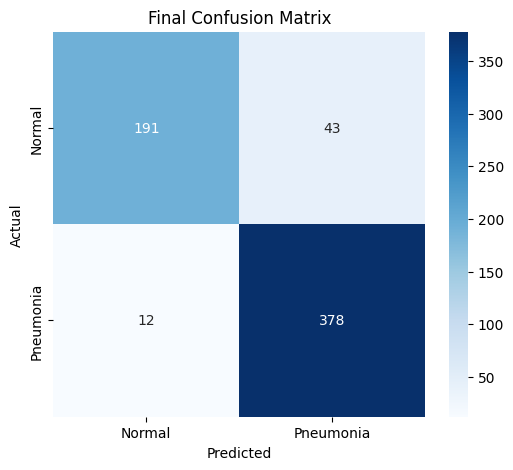

In [9]:
import numpy as np
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the test data
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# 2. Predict using the trained model
print("Final Evaluation on Test Dataset...")
preds = model.predict(test_generator)
y_pred = (preds > 0.5).astype(int).flatten()
y_true = test_generator.classes

# 3. Output Results
print("\n" + "="*30)
print("FINAL PROJECT METRICS")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))
print(f"Final F1-Score: {f1_score(y_true, y_pred):.4f}")

# 4. Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Final Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [10]:
# Save the final state of the model after all 30 epochs
FINAL_MODEL_PATH = '/content/drive/MyDrive/pneumonia_model_final_epoch30.h5'
model.save(FINAL_MODEL_PATH)
print(f"Final model saved successfully to: {FINAL_MODEL_PATH}")

Final model saved successfully to: /content/drive/MyDrive/pneumonia_model_final_epoch30.h5


In [11]:
from tensorflow.keras.models import load_model

if os.path.exists(MODEL_SAVE_PATH):
    model = load_model(MODEL_SAVE_PATH)
    print("Model successfully retrieved from your Google Drive!")
else:
    print("Model file not found. Ensure your Drive is mounted.")

Model successfully retrieved from your Google Drive!


Saving person1947_bacteria_4876.jpeg to person1947_bacteria_4876.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
The model is 92.69% confident that this is PNEUMONIA.


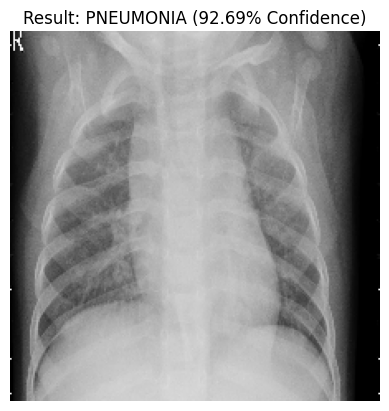

In [13]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Upload the file
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Preprocess the image
    img_path = filename
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert to array and normalize
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array /= 255.0 # Rescale pixels to [0,1]

    # 3. Predict
    prediction = model.predict(img_array)

    # 4. Display Result
    plt.imshow(img)
    plt.axis('off')

    if prediction[0] > 0.5:
        confidence = prediction[0][0] * 100
        plt.title(f"Result: PNEUMONIA ({confidence:.2f}% Confidence)")
        print(f"The model is {confidence:.2f}% confident that this is PNEUMONIA.")
    else:
        confidence = (1 - prediction[0][0]) * 100
        plt.title(f"Result: NORMAL ({confidence:.2f}% Confidence)")
        print(f"The model is {confidence:.2f}% confident that this is NORMAL.")

    plt.show()
    .0